In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# load data

X_test = np.load('X_test.npy')
X_train = np.load('X_train.npy')
y_test = np.load('y_test.npy')
y_train = np.load('y_train.npy')

Before performing any training, we normalize the dataset.

In [3]:
# normalization

X_test = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)
X_train = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)
y_test = (y_test - y_test.mean(axis=0)) / y_test.std(axis=0)
y_train = (y_train - y_train.mean(axis=0)) / y_train.std(axis=0)

We compare 3 models: linear regression, ridge and lasso. For ridge and lasso, we use cross validation to compute the best regularisation parameters.

In [4]:
# train and pred

lr = LinearRegression()
rd = RidgeCV(alphas=np.logspace(-6, 6), cv=5)
ls = LassoCV(cv=5)

lr.fit(X_train, y_train)
rd.fit(X_train, y_train)
ls.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
rd_pred = rd.predict(X_test)
ls_pred = ls.predict(X_test)

/home/theodore/epita/FTML/project-repos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1835: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


To evaluate the models, we compute MSE and R2 score. Basic linear regression is totally overfitted because of too few samples (200 samples for 200 features). Lasso is the only model to achieve the goal of 0.88 of R2 score.

In [ ]:
# evaluate

lr_mse = mean_squared_error(y_test, lr_pred)
rd_mse = mean_squared_error(y_test, rd_pred)
ls_mse = mean_squared_error(y_test, ls_pred)

lr_r2 = r2_score(y_test, lr_pred)
rd_r2 = r2_score(y_test, rd_pred)
ls_r2 = r2_score(y_test, ls_pred)

print(f"Linear Regression mse: {lr_mse}")
print(f"Ridge mse: {rd_mse}")
print(f"Lasso mse: {ls_mse}")

print(f"Linear Regression R2 Score: {lr_r2}")
print(f"Ridge R2 Score: {rd_r2}")
print(f"Lasso R2 Score: {ls_r2}")

Linear Regression mse: 8.894293891450973
linear regression train score: 1.0
Ridge mse: 0.26873919988659056
Lasso mse: 0.0904315170918482
Linear Regression R2 Score: -7.894293891450975
Ridge R2 Score: 0.7312608001134093
Lasso R2 Score: 0.9095684829081518


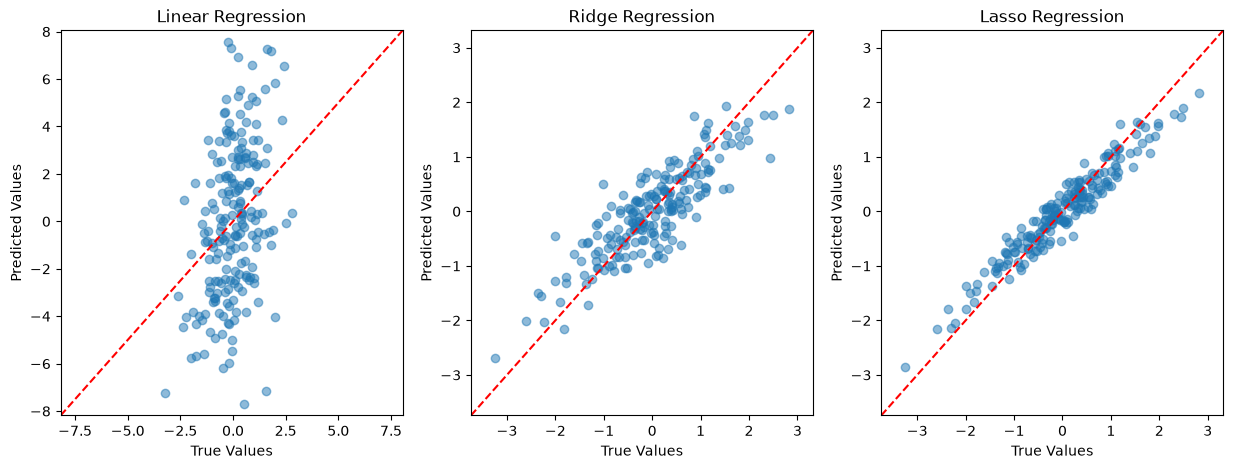

In [6]:
# plot

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
models = [("Linear Regression", lr_pred), ("Ridge Regression", rd_pred), ("Lasso Regression", ls_pred)]

for i, (title, pred) in enumerate(models):
    lims = [
        min(y_test.min(), pred.min()) - 0.5, 
        max(y_test.max(), pred.max()) + 0.5, 
    ]
    axs[i].scatter(y_test, pred, alpha=0.5)
    axs[i].plot(lims, lims, 'r--')
    axs[i].set_xlabel("True Values")
    axs[i].set_ylabel("Predicted Values")
    axs[i].set_title(title)
    axs[i].set_xlim(lims)
    axs[i].set_ylim(lims)

plt.show()